# Social Media Engagement Analysis
This notebook loads the dataset and performs a quick exploratory analysis and simple visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
print("working")

Matplotlib is building the font cache; this may take a moment.


working


In [3]:
# Load dataset (adjust path if needed)
df = pd.read_csv('../data/social_media_engagement_dataset.csv')
df.head(500)

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,POST_04081,2024-03-19 03:32:00,LinkedIn,Poll,Entertainment,1913,17,389,4609,11,283849,0.82,3,Tuesday,13,394,Positive,Macro,True,False
496,POST_03201,2024-03-19 03:52:00,Facebook,Story,Travel,3173,182,563,66065,366,41003,9.56,3,Tuesday,26,1061,Positive,Micro,True,False
497,POST_04924,2024-03-19 06:43:00,TikTok,Video,Travel,9018,1841,1841,105120,141,219831,5.78,6,Tuesday,6,408,Negative,Macro,True,False
498,POST_03503,2024-03-19 07:49:00,YouTube,Live,Business,13873,125,1399,660216,1095,19195,80.21,7,Tuesday,6,573,Negative,Micro,False,False


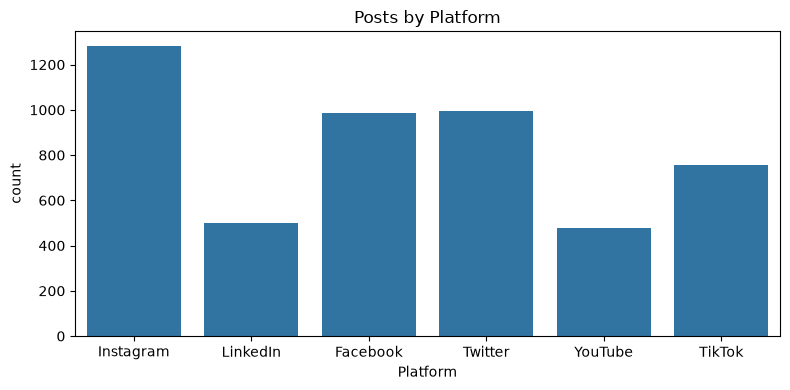

In [5]:
# Simple example plot: posts by platform (requires a 'Platform' column)
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Platform')
plt.title('Posts by Platform')
plt.tight_layout()
plt.show()

In [8]:
print(df.shape)

(5000, 20)


In [9]:
print(df.columns.tolist())

['Post_ID', 'Timestamp', 'Platform', 'Content_Type', 'Category', 'Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Follower_Count', 'Engagement_Rate', 'Hour_of_Day', 'Day_of_Week', 'Hashtag_Count', 'Content_Length', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified']


In [10]:
print(df.isnull().sum())

Post_ID            0
Timestamp          0
Platform           0
Content_Type       0
Category           0
Likes              0
Comments           0
Shares             0
Views              0
Saves              0
Follower_Count     0
Engagement_Rate    0
Hour_of_Day        0
Day_of_Week        0
Hashtag_Count      0
Content_Length     0
Sentiment          0
Influencer_Tier    0
Has_Media          0
Is_Verified        0
dtype: int64


In [12]:
print(df.duplicated().sum())

0


In [13]:
print(df["Platform"].value_counts())

Platform
Instagram    1283
Twitter       994
Facebook      984
TikTok        758
LinkedIn      502
YouTube       479
Name: count, dtype: int64


In [15]:
df["Total_Engagement"] = (
    df["Likes"] +
    df["Comments"] +
    df["Shares"]
)

In [16]:
platform_summary = df.groupby("Platform").agg(
    Posts=("Post_ID", "count"),
    Avg_Likes=("Likes", "mean"),
    Avg_Comments=("Comments", "mean"),
    Avg_Shares=("Shares", "mean"),
    Avg_Views=("Views", "mean"),
    Avg_Engagement=("Total_Engagement", "mean"),
    Avg_Engagement_Rate=("Engagement_Rate", "mean")
).round(2)

platform_summary

,Posts,Avg_Likes,Avg_Comments,Avg_Shares,Avg_Views,Avg_Engagement,Avg_Engagement_Rate
Platform,,,,,,,
Facebook,984,4148.18,197.40,494.51,40565.07,4840.08,7.17
Instagram,1283,4943.33,241.16,150.96,24898.54,5335.45,8.12
LinkedIn,502,1035.37,75.41,256.62,14834.96,1367.39,1.75
TikTok,758,25799.96,1020.76,2499.89,251998.89,29320.61,41.83
Twitter,994,2419.64,147.91,1007.83,49634.95,3575.38,4.76
YouTube,479,9976.72,495.27,981.99,490984.70,11453.97,10.46


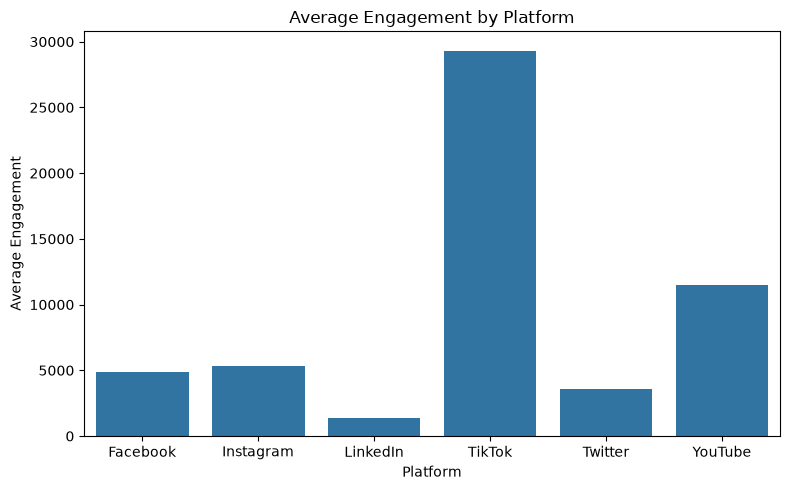

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=platform_summary.reset_index(),
    x="Platform",
    y="Avg_Engagement"
)

plt.title("Average Engagement by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Engagement")
plt.tight_layout()
plt.show()

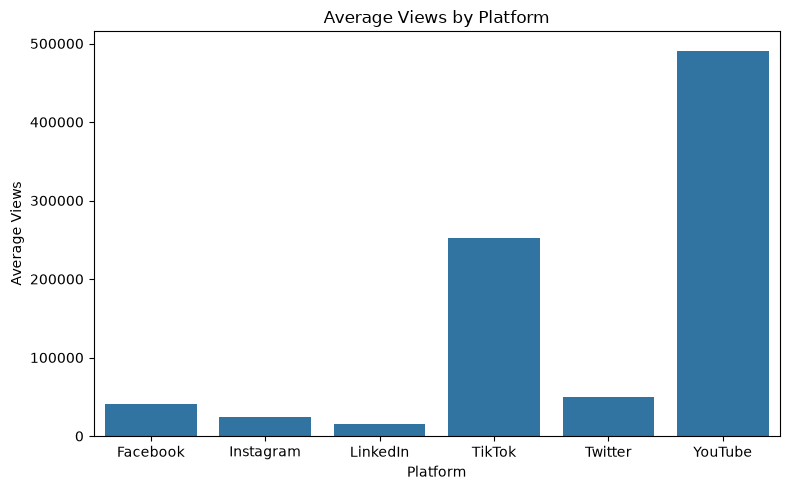

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=platform_summary.reset_index(),
    x="Platform",
    y="Avg_Views"
)

plt.title("Average Views by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Views")
plt.tight_layout()
plt.show()

In [19]:
print(df["Content_Type"].value_counts())

Content_Type
Video             616
Story             568
Poll              384
Post              378
Live              358
Carousel          333
Photo             320
Reel              306
Stitch            259
Retweet           251
Duet              248
Tweet             239
Thread            236
Community Post    135
Document          132
Short             121
Article           116
Name: count, dtype: int64


In [20]:
content_summary = df.groupby("Content_Type").agg(
    Posts=("Post_ID", "count"),
    Avg_Likes=("Likes", "mean"),
    Avg_Comments=("Comments", "mean"),
    Avg_Shares=("Shares", "mean"),
    Avg_Views=("Views", "mean"),
    Avg_Engagement=("Total_Engagement", "mean"),
    Avg_Engagement_Rate=("Engagement_Rate", "mean")
).round(2)

content_summary

,Posts,Avg_Likes,Avg_Comments,Avg_Shares,Avg_Views,Avg_Engagement,Avg_Engagement_Rate
Content_Type,,,,,,,
Article,116,1092.41,81.77,254.79,14344.42,1428.97,1.45
Carousel,333,5039.28,240.31,146.58,25160.35,5426.18,8.38
Community Post,135,9907.99,483.79,1016.99,461787.51,11408.76,10.19
Document,132,975.64,75.76,272.89,15160.31,1324.29,1.18
Duet,248,26245.49,1058.09,2520.33,239033.77,29823.91,41.63
Live,358,6182.15,316.35,674.88,186881.94,7173.37,7.41
Photo,320,4809.24,243.38,151.32,24922.18,5203.94,6.28
Poll,384,1977.29,125.76,786.55,40860.56,2889.59,3.28
Post,378,3222.08,147.75,400.47,30905.13,3770.30,7.71


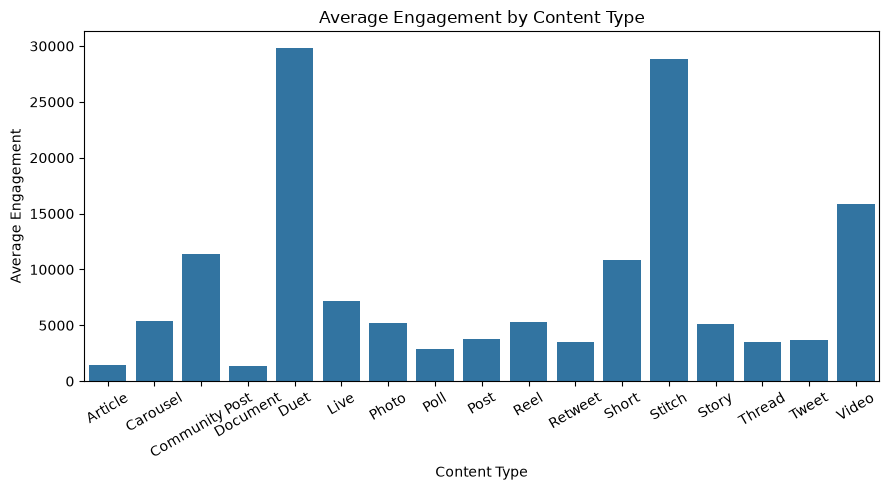

In [22]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=content_summary.reset_index(),
    x="Content_Type",
    y="Avg_Engagement"
)

plt.title("Average Engagement by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average Engagement")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [23]:
day_summary = df.groupby("Day_of_Week").agg(
    Posts=("Post_ID", "count"),
    Avg_Likes=("Likes", "mean"),
    Avg_Comments=("Comments", "mean"),
    Avg_Shares=("Shares", "mean"),
    Avg_Engagement=("Total_Engagement", "mean"),
    Avg_Views=("Views", "mean")
).round(2)

day_summary

,Posts,Avg_Likes,Avg_Comments,Avg_Shares,Avg_Engagement,Avg_Views
Day_of_Week,,,,,,
Friday,711,7295.18,334.58,845.17,8474.93,109424.70
Monday,719,7370.42,322.77,790.26,8483.45,101922.56
Saturday,705,7244.59,331.74,817.31,8393.65,101770.04
Sunday,706,7023.67,314.45,834.15,8172.26,121699.78
Thursday,715,7818.32,353.75,858.02,9030.10,104380.34
Tuesday,717,7695.58,350.54,842.62,8888.74,122294.59
Wednesday,727,8286.11,370.54,858.73,9515.39,115231.93


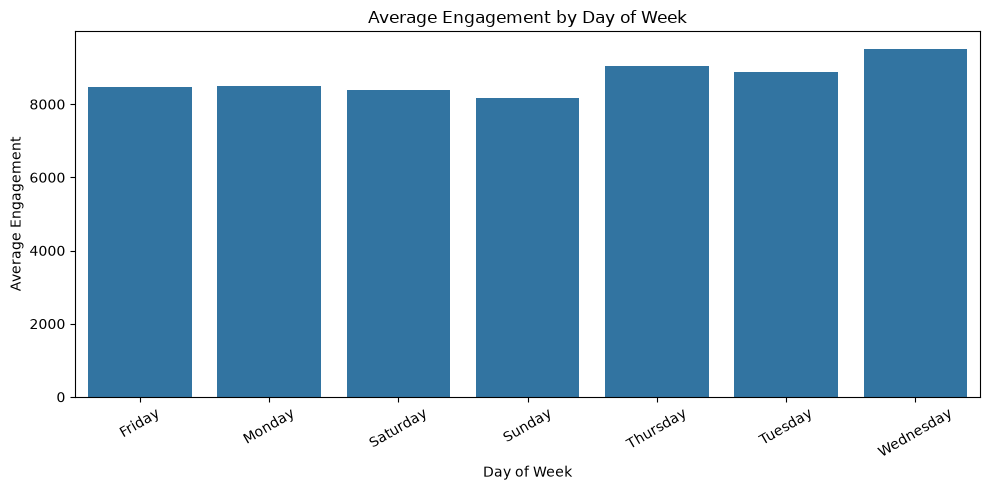

In [24]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=day_summary.reset_index(),
    x="Day_of_Week",
    y="Avg_Engagement"
)

plt.title("Average Engagement by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Engagement")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [25]:
hour_summary = df.groupby("Hour_of_Day").agg(
    Posts=("Post_ID", "count"),
    Avg_Engagement=("Total_Engagement", "mean"),
    Avg_Views=("Views", "mean")
).round(2)

hour_summary

,Posts,Avg_Engagement,Avg_Views
Hour_of_Day,,,
0,196,8887.85,96966.92
1,207,9233.73,109144.31
2,208,8390.58,114714.89
3,218,8134.00,98247.22
4,233,8142.79,116976.61
5,192,8472.33,104849.26
6,200,8637.89,115668.15
7,200,8840.12,109032.76
8,208,7617.17,111826.76


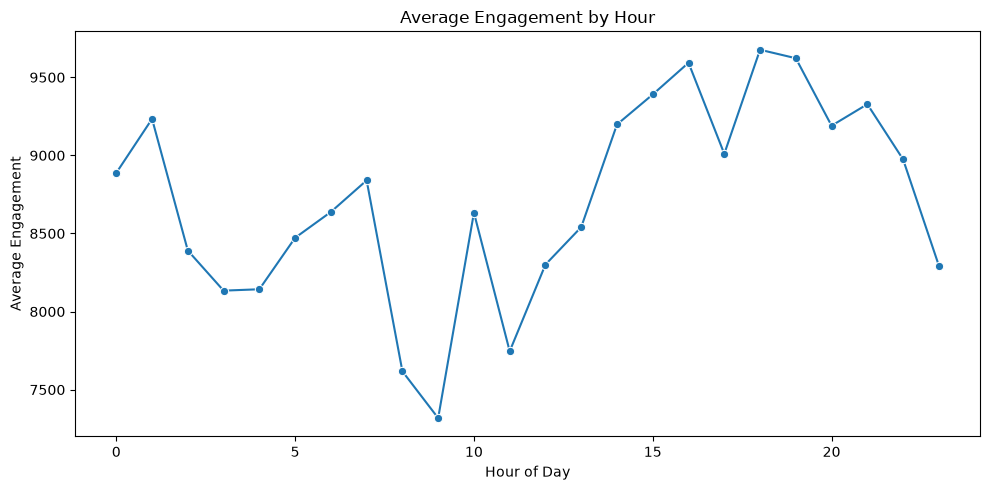

In [26]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_summary.reset_index(),
    x="Hour_of_Day",
    y="Avg_Engagement",
    marker="o"
)

plt.title("Average Engagement by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Engagement")
plt.tight_layout()
plt.show()

In [27]:
category_summary = df.groupby("Category").agg(
    Posts=("Post_ID", "count"),
    Avg_Likes=("Likes", "mean"),
    Avg_Comments=("Comments", "mean"),
    Avg_Shares=("Shares", "mean"),
    Avg_Views=("Views", "mean"),
    Avg_Engagement=("Total_Engagement", "mean"),
    Avg_Engagement_Rate=("Engagement_Rate", "mean")
).round(2)

category_summary

,Posts,Avg_Likes,Avg_Comments,Avg_Shares,Avg_Views,Avg_Engagement,Avg_Engagement_Rate
Category,,,,,,,
Business,382,6642.77,326.13,780.50,107718.95,7749.40,11.96
Education,413,8054.63,362.25,886.59,123764.61,9303.47,11.89
Entertainment,432,8163.24,351.75,864.35,121652.71,9379.34,11.57
Fashion,428,6651.74,295.58,793.51,102640.57,7740.83,7.61
Fitness,393,7415.51,328.70,811.80,104368.37,8556.01,10.38
Food,413,8172.51,352.51,913.29,109709.08,9438.30,12.95
Gaming,476,7239.80,336.24,806.28,105738.98,8382.32,9.91
Health,397,7599.65,357.58,856.83,127130.53,8814.06,9.32
Lifestyle,433,7421.37,317.22,807.45,103738.81,8546.04,19.13


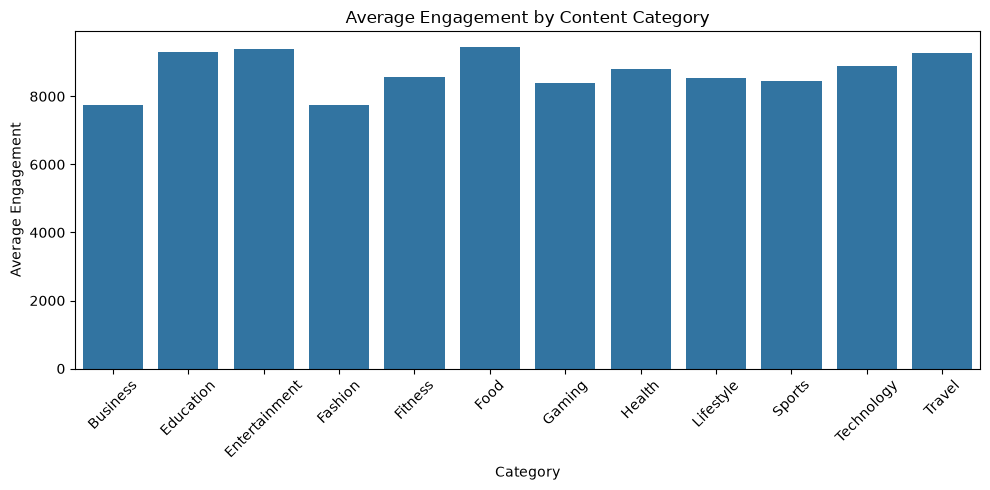

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_summary.reset_index(),
    x="Category",
    y="Avg_Engagement"
)

plt.title("Average Engagement by Content Category")
plt.xlabel("Category")
plt.ylabel("Average Engagement")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

daily_engagement = df.groupby(
    df["Timestamp"].dt.date
).agg(
    Avg_Engagement=("Total_Engagement", "mean"),
    Avg_Views=("Views", "mean"),
    Posts=("Post_ID", "count")
)

daily_engagement.head()

,Avg_Engagement,Avg_Views,Posts
Timestamp,,,
2024-01-01,4660.000000,30705.600000,5
2024-01-02,5414.875000,159192.375000,8
2024-01-03,5044.000000,39533.400000,5
2024-01-04,6952.142857,153267.714286,7
2024-01-05,4095.666667,14928.666667,3


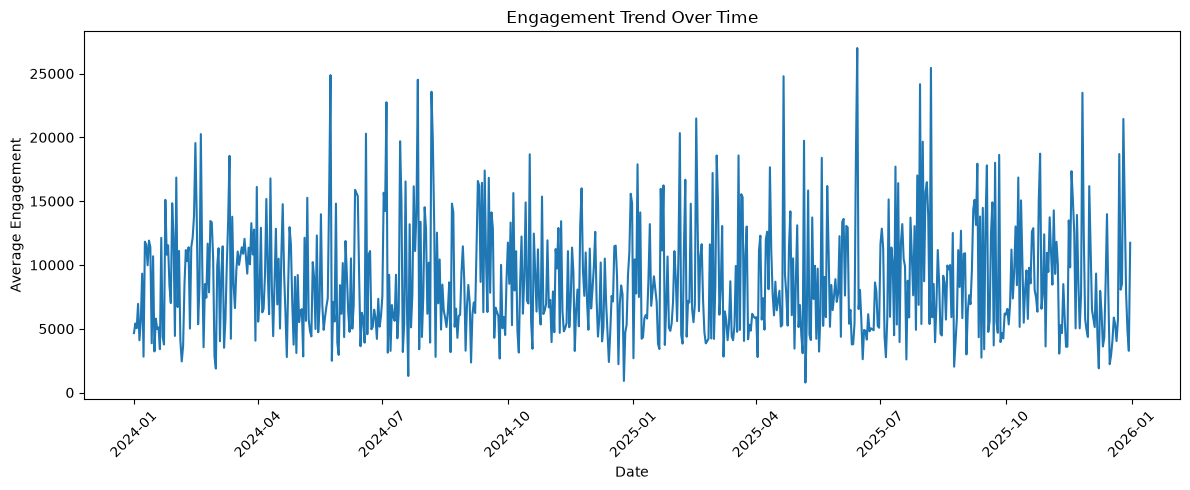

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_engagement.index,
    daily_engagement["Avg_Engagement"]
)

plt.title("Engagement Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Engagement")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
interaction_summary = df[[
    "Likes",
    "Comments",
    "Shares"
]].mean().round(2)

interaction_summary

Likes       7536.84
Comments     339.90
Shares       835.23
dtype: float64

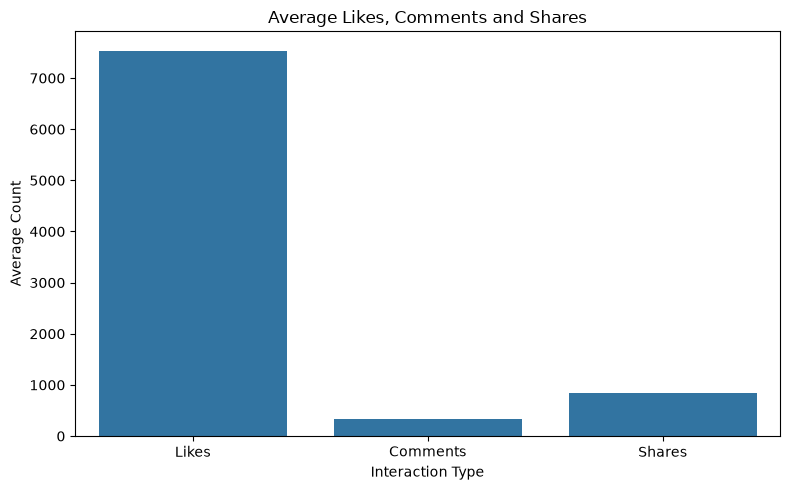

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=interaction_summary.index,
    y=interaction_summary.values
)

plt.title("Average Likes, Comments and Shares")
plt.xlabel("Interaction Type")
plt.ylabel("Average Count")
plt.tight_layout()
plt.show()

In [33]:
print("Dataset Shape:", df.shape)

print("Missing Values:")
print(df.isnull().sum())
print("Duplicate Rows:")
print("\nDuplicate Rows:")
print("Platforms:")

print("Content Types:")
print(df["Platform"].value_counts())

print("\nContent Types:")
print(df["Content_Type"].value_counts());0

Dataset Shape: (5000, 21)

Missing Values:
Post_ID             0
Timestamp           0
Platform            0
Content_Type        0
Category            0
Likes               0
Comments            0
Shares              0
Views               0
Saves               0
Follower_Count      0
Engagement_Rate     0
Hour_of_Day         0
Day_of_Week         0
Hashtag_Count       0
Content_Length      0
Sentiment           0
Influencer_Tier     0
Has_Media           0
Is_Verified         0
Total_Engagement    0
dtype: int64

Duplicate Rows:
0

Platforms:
Platform
Instagram    1283
Twitter       994
Facebook      984
TikTok        758
LinkedIn      502
YouTube       479
Name: count, dtype: int64

Content Types:
Content_Type
Video             616
Story             568
Poll              384
Post              378
Live              358
Carousel          333
Photo             320
Reel              306
Stitch            259
Retweet           251
Duet              248
Tweet             239
Thread         

In [34]:
print("Data Types:")
print(df.dtypes)



Data Types:
Post_ID                        str
Timestamp           datetime64[us]
Platform                       str
Content_Type                   str
Category                       str
Likes                        int64
Comments                     int64
Shares                       int64
Views                        int64
Saves                        int64
Follower_Count               int64
Engagement_Rate            float64
Hour_of_Day                  int64
Day_of_Week                    str
Hashtag_Count                int64
Content_Length               int64
Sentiment                      str
Influencer_Tier                str
Has_Media                     bool
Is_Verified                   bool
Total_Engagement             int64
dtype: object


In [38]:
media_summary = df.groupby("Has_Media").agg(
    Posts=("Post_ID", "count"),
    Avg_Likes=("Likes", "mean"),
    Avg_Comments=("Comments", "mean"),
    Avg_Shares=("Shares", "mean"),
    Avg_Views=("Views", "mean"),
    Avg_Engagement=("Total_Engagement", "mean"),
    Avg_Engagement_Rate=("Engagement_Rate", "mean")
).round(2)

media_summary

,Posts,Avg_Likes,Avg_Comments,Avg_Shares,Avg_Views,Avg_Engagement,Avg_Engagement_Rate
Has_Media,,,,,,,
False,775,7450.98,312.94,822.59,117779.72,8586.51,15.62
True,4225,7552.59,344.84,837.55,109718.98,8734.98,11.29


In [39]:
sentiment_summary = df.groupby("Sentiment").agg(
    Posts=("Post_ID", "count"),
    Avg_Likes=("Likes", "mean"),
    Avg_Comments=("Comments", "mean"),
    Avg_Shares=("Shares", "mean"),
    Avg_Views=("Views", "mean"),
    Avg_Engagement=("Total_Engagement", "mean"),
    Avg_Engagement_Rate=("Engagement_Rate", "mean")
).round(2)

sentiment_summary

,Posts,Avg_Likes,Avg_Comments,Avg_Shares,Avg_Views,Avg_Engagement,Avg_Engagement_Rate
Sentiment,,,,,,,
Negative,750,7161.85,331.62,817.76,105649.56,8311.22,11.87
Neutral,1747,7315.31,333.08,852.35,107405.70,8500.74,10.65
Positive,2503,7803.82,347.14,828.52,115048.77,8979.48,12.90


In [40]:
platform_summary.to_csv("../report/platform_summary.csv")
content_summary.to_csv("../report/content_summary.csv")
category_summary.to_csv("../report/category_summary.csv")
day_summary.to_csv("../report/day_summary.csv")
hour_summary.to_csv("../report/hour_summary.csv")
sentiment_summary.to_csv("../report/sentiment_summary.csv")
media_summary.to_csv("../report/media_summary.csv")
interaction_summary.to_csv("../report/interaction_summary.csv")

In [41]:
print("=== PLATFORM ===")
print(platform_summary)

print("\n=== CONTENT TYPE ===")
print(content_summary)

print("\n=== CATEGORY ===")
print(category_summary)

print("\n=== DAY ===")
print(day_summary)

print("\n=== HOUR ===")
print(hour_summary)

print("\n=== SENTIMENT ===")
print(sentiment_summary)

print("\n=== MEDIA ===")
print(media_summary)

print("\n=== INTERACTIONS ===")
print(interaction_summary)

=== PLATFORM ===
           Posts  Avg_Likes  Avg_Comments  Avg_Shares  Avg_Views  \
Platform                                                           
Facebook     984    4148.18        197.40      494.51   40565.07   
Instagram   1283    4943.33        241.16      150.96   24898.54   
LinkedIn     502    1035.37         75.41      256.62   14834.96   
TikTok       758   25799.96       1020.76     2499.89  251998.89   
Twitter      994    2419.64        147.91     1007.83   49634.95   
YouTube      479    9976.72        495.27      981.99  490984.70   

           Avg_Engagement  Avg_Engagement_Rate  
Platform                                        
Facebook          4840.08                 7.17  
Instagram         5335.45                 8.12  
LinkedIn          1367.39                 1.75  
TikTok           29320.61                41.83  
Twitter           3575.38                 4.76  
YouTube          11453.97                10.46  

=== CONTENT TYPE ===
                Posts  A

In [42]:
print("Highest Platform by Average Engagement:")
print(platform_summary["Avg_Engagement"].idxmax())

print("\nHighest Content Type by Average Engagement:")
print(content_summary["Avg_Engagement"].idxmax())

print("\nHighest Category by Average Engagement:")
print(category_summary["Avg_Engagement"].idxmax())

print("\nHighest Day by Average Engagement:")
print(day_summary["Avg_Engagement"].idxmax())

print("\nHighest Hour by Average Engagement:")
print(hour_summary["Avg_Engagement"].idxmax())

print("\nHighest Sentiment by Average Engagement:")
print(sentiment_summary["Avg_Engagement"].idxmax())

print("\nMedia Performance:")
print(media_summary["Avg_Engagement"])

Highest Platform by Average Engagement:
TikTok

Highest Content Type by Average Engagement:
Duet

Highest Category by Average Engagement:
Food

Highest Day by Average Engagement:
Wednesday

Highest Hour by Average Engagement:
18

Highest Sentiment by Average Engagement:
Positive

Media Performance:
Has_Media
False    8586.51
True     8734.98
Name: Avg_Engagement, dtype: float64
